# Workforce Intelligence — EDA & Data Analysis

**Goal:** Understand the datasets, market patterns, skill demand, salary patterns, and statistical relationships.

## Flow

**Data → Quality → EDA → Market Analysis → Skill Analysis → Statistical Analysis → Findings**

In [1]:

# 1. Environment

%pip install -q pandas numpy scipy statsmodels scikit-learn matplotlib seaborn openpyxl networkx


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

# 2. Imports and display configuration

import os, re, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("READY — libraries loaded")


READY — libraries loaded


In [3]:

# 3. Explicit dataset paths

DATA_DIR = Path(r"C:\Users\024ni\OneDrive\Desktop\projectxxxx")

PATHS = {
    "data_science": DATA_DIR / "DataScience Jobs.csv",
    "analytics": DATA_DIR / "Analytics Jobs.csv",
    "jds": DATA_DIR / "JDS Skill Traits.xlsx",
    "sds": DATA_DIR / "SDS Personality Traits.xlsx",
}

for name, path in PATHS.items():
    print(f"{name:15s} -> {path} | exists={path.exists()}")

missing = [str(p) for p in PATHS.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing dataset(s):\n" + "\n".join(missing))


data_science    -> C:\Users\024ni\OneDrive\Desktop\projectxxxx\DataScience Jobs.csv | exists=True
analytics       -> C:\Users\024ni\OneDrive\Desktop\projectxxxx\Analytics Jobs.csv | exists=True
jds             -> C:\Users\024ni\OneDrive\Desktop\projectxxxx\JDS Skill Traits.xlsx | exists=True
sds             -> C:\Users\024ni\OneDrive\Desktop\projectxxxx\SDS Personality Traits.xlsx | exists=True


In [4]:

# 4. Load datasets

ds_jobs = pd.read_csv(PATHS["data_science"])
analytics_jobs = pd.read_csv(PATHS["analytics"])
jds = pd.read_excel(PATHS["jds"])
sds = pd.read_excel(PATHS["sds"])

print("DATA LOADED")
print("DataScience Jobs :", ds_jobs.shape)
print("Analytics Jobs   :", analytics_jobs.shape)
print("JDS Skill Traits :", jds.shape)
print("SDS Personality  :", sds.shape)


DATA LOADED
DataScience Jobs : (1602, 8)
Analytics Jobs   : (15841, 8)
JDS Skill Traits : (139, 7)
SDS Personality  : (161, 7)


In [5]:

# 5. Robust column-name normalization

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

ds_jobs = clean_column_names(ds_jobs)
analytics_jobs = clean_column_names(analytics_jobs)
jds = clean_column_names(jds)
sds = clean_column_names(sds)

for name, df in {
    "DataScience Jobs": ds_jobs,
    "Analytics Jobs": analytics_jobs,
    "JDS": jds,
    "SDS": sds
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())



DataScience Jobs
['reference_no', 'company_name', 'job_title', 'min_experience', 'avg_salary', 'min_salary', 'max_salary', 'num_of_jobs']

Analytics Jobs
['s_no', 'experience', 'job_description', 'job_desig', 'job_type', 'key_skills', 'location', 'salary']

JDS
['id', 'big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills', 'salary_hike_high_or_low']

SDS
['id', 'neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness', 'success_classification_high_low']


# 6. Data-quality audit

In [6]:

def audit_table(df, name):
    rows = []
    for c in df.columns:
        rows.append({
            "dataset": name,
            "column": c,
            "dtype": str(df[c].dtype),
            "missing_n": int(df[c].isna().sum()),
            "missing_pct": 100 * df[c].isna().mean(),
            "unique_n": int(df[c].nunique(dropna=True)),
            "constant": df[c].nunique(dropna=True) <= 1
        })
    return pd.DataFrame(rows)

audit = pd.concat([
    audit_table(ds_jobs, "DataScience Jobs"),
    audit_table(analytics_jobs, "Analytics Jobs"),
    audit_table(jds, "JDS"),
    audit_table(sds, "SDS")
], ignore_index=True)

display(audit.sort_values(["dataset", "missing_pct"], ascending=[True, False]))


,dataset,column,dtype,missing_n,missing_pct,unique_n,constant
12,Analytics Jobs,job_type,object,12011,75.8222,5,False
10,Analytics Jobs,job_description,object,3508,22.1451,7859,False
13,Analytics Jobs,key_skills,object,1,0.0063,11155,False
8,Analytics Jobs,s_no,int64,0,0.0000,15841,False
9,Analytics Jobs,experience,object,0,0.0000,128,False
11,Analytics Jobs,job_desig,object,0,0.0000,10097,False
14,Analytics Jobs,location,object,0,0.0000,1355,False
15,Analytics Jobs,salary,object,0,0.0000,6,False
0,DataScience Jobs,reference_no,int64,0,0.0000,1460,False
1,DataScience Jobs,company_name,object,0,0.0000,642,False


In [7]:

# Duplicate audit

for name, df in {
    "DataScience Jobs": ds_jobs,
    "Analytics Jobs": analytics_jobs,
    "JDS": jds,
    "SDS": sds
}.items():
    exact_dup = int(df.duplicated().sum())
    print(f"{name:20s} | rows={len(df):,} | exact duplicates={exact_dup:,}")


DataScience Jobs     | rows=1,602 | exact duplicates=0
Analytics Jobs       | rows=15,841 | exact duplicates=0
JDS                  | rows=139 | exact duplicates=0
SDS                  | rows=161 | exact duplicates=0


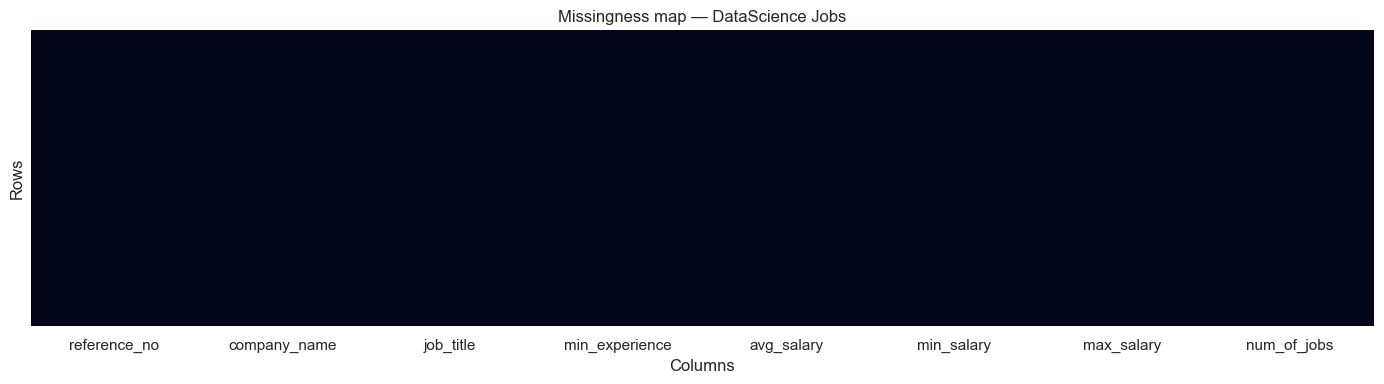

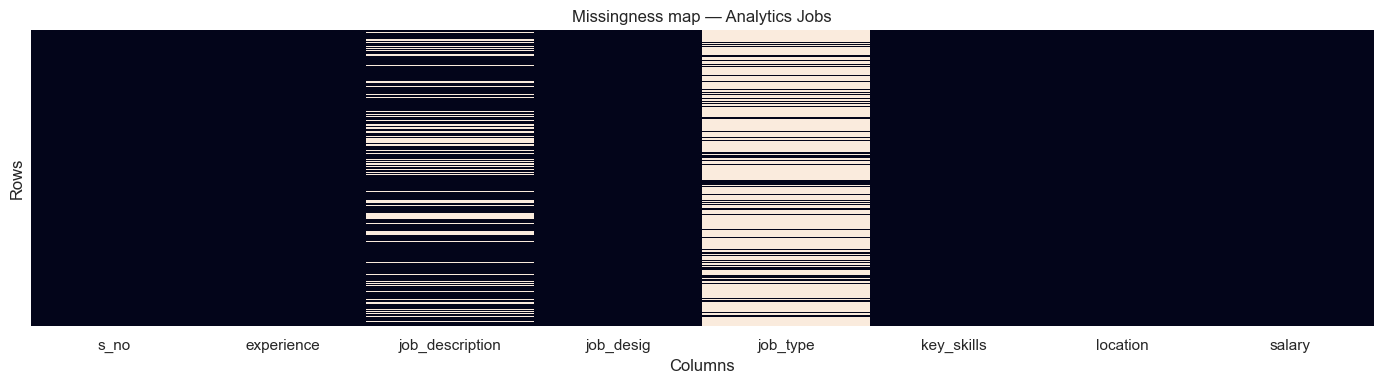

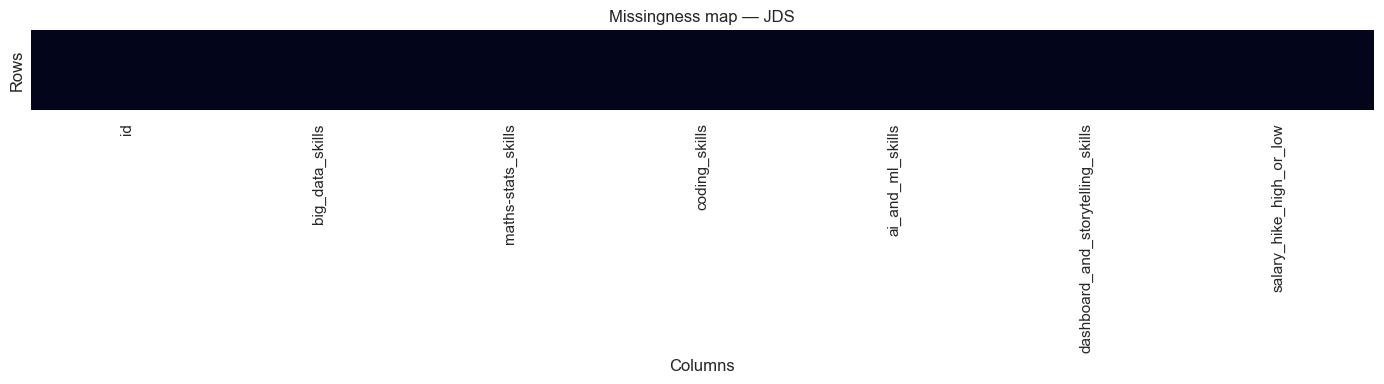

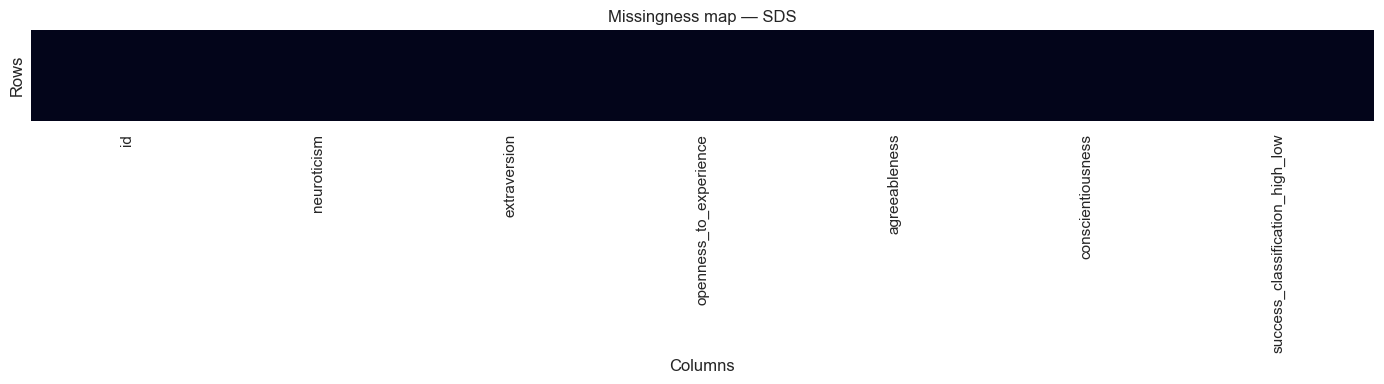

In [8]:

# Missingness heatmaps — one per dataset

datasets = [
    ("DataScience Jobs", ds_jobs),
    ("Analytics Jobs", analytics_jobs),
    ("JDS", jds),
    ("SDS", sds),
]

for name, df in datasets:
    plt.figure(figsize=(14, max(4, min(10, len(df.columns)*0.35))))
    sns.heatmap(df.isna(), cbar=False, yticklabels=False)
    plt.title(f"Missingness map — {name}")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()


# 7. Univariate EDA

In [9]:

def numeric_summary(df, name):
    num = df.select_dtypes(include=np.number)
    if num.empty:
        return pd.DataFrame()
    out = num.describe().T
    out["missing_pct"] = num.isna().mean() * 100
    out["skewness"] = num.skew()
    out["kurtosis"] = num.kurtosis()
    out["iqr"] = out["75%"] - out["25%"]
    out["iqr_low"] = out["25%"] - 1.5*out["iqr"]
    out["iqr_high"] = out["75%"] + 1.5*out["iqr"]
    return out.sort_values("skewness", key=lambda s: s.abs(), ascending=False)

for name, df in datasets:
    print("\n###", name)
    display(numeric_summary(df, name))



### DataScience Jobs


,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness,kurtosis,iqr,iqr_low,iqr_high
num_of_jobs,"1,602.0000",58.0556,169.0421,3.0000,9.2500,22.0000,47.0000,"4,200.0000",0.0000,12.7977,251.0679,37.7500,-47.3750,103.6250
min_experience,"1,602.0000",2.7990,2.3537,0.0000,1.0000,2.0000,4.0000,21.0000,0.0000,1.7649,5.6038,3.0000,-3.5000,8.5000
reference_no,"1,602.0000","5,105.7890","2,291.9377","1,012.0000","3,225.2500","5,200.5000","7,022.5000","8,998.0000",0.0000,-0.0404,-1.1323,"3,797.2500","-2,470.6250","12,718.3750"



### Analytics Jobs


,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness,kurtosis,iqr,iqr_low,iqr_high
s_no,"15,841.0000","7,921.0000","4,573.0471",1.0000,"3,961.0000","7,921.0000","11,881.0000","15,841.0000",0.0000,0.0000,-1.2000,"7,920.0000","-7,919.0000","23,761.0000"



### JDS


,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness,kurtosis,iqr,iqr_low,iqr_high
ai_and_ml_skills,139.0000,4.5662,0.6671,2.2000,4.4000,4.9000,5.0000,5.0000,0.0000,-1.7048,1.9944,0.6000,3.5000,5.9000
dashboard_and_storytelling_skills,139.0000,4.3554,0.9331,2.3000,3.7500,5.0000,5.0000,5.0000,0.0000,-1.0789,-0.4793,1.2500,1.8750,6.8750
maths-stats_skills,139.0000,4.2935,0.8439,2.2000,3.8000,4.6000,5.0000,5.0000,0.0000,-0.9727,-0.2903,1.2000,2.0000,6.8000
coding_skills,139.0000,4.2683,0.8930,2.2000,3.3500,4.6000,5.0000,5.0000,0.0000,-0.8899,-0.6750,1.6500,0.8750,7.4750
salary_hike_high_or_low,139.0000,0.5252,0.5012,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,-0.1020,-2.0189,1.0000,-1.5000,2.5000
big_data_skills,139.0000,3.8496,0.8466,2.3000,3.1000,3.8000,4.6000,5.0000,0.0000,-0.0809,-1.2153,1.5000,0.8500,6.8500
id,139.0000,"2,958.4604",604.5387,"2,007.0000","2,383.5000","2,963.0000","3,452.0000","4,000.0000",0.0000,0.0357,-1.3202,"1,068.5000",780.7500,"5,054.7500"



### SDS


,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness,kurtosis,iqr,iqr_low,iqr_high
neuroticism,161.0000,36.1925,11.2680,17.0000,27.0000,34.0000,44.0000,68.0000,0.0000,0.7216,0.0953,17.0000,1.5000,69.5000
conscientiousness,161.0000,45.2112,13.2119,18.0000,35.0000,49.0000,56.0000,66.0000,0.0000,-0.5343,-0.9540,21.0000,3.5000,87.5000
agreeableness,161.0000,44.6025,11.2934,17.0000,39.0000,46.0000,51.0000,68.0000,0.0000,-0.4416,-0.1868,12.0000,21.0000,69.0000
openness_to_experience,161.0000,41.3292,11.3224,18.0000,32.0000,44.0000,49.0000,65.0000,0.0000,-0.3805,-0.7015,17.0000,6.5000,74.5000
extraversion,161.0000,43.2050,12.1347,17.0000,34.0000,45.0000,53.0000,67.0000,0.0000,-0.3177,-0.7397,19.0000,5.5000,81.5000
success_classification_high_low,161.0000,0.5280,0.5008,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,-0.1130,-2.0124,1.0000,-1.5000,2.5000
id,161.0000,"8,484.5963",280.3575,"8,001.0000","8,228.0000","8,504.0000","8,729.0000","8,979.0000",0.0000,-0.0096,-1.2364,501.0000,"7,476.5000","9,480.5000"


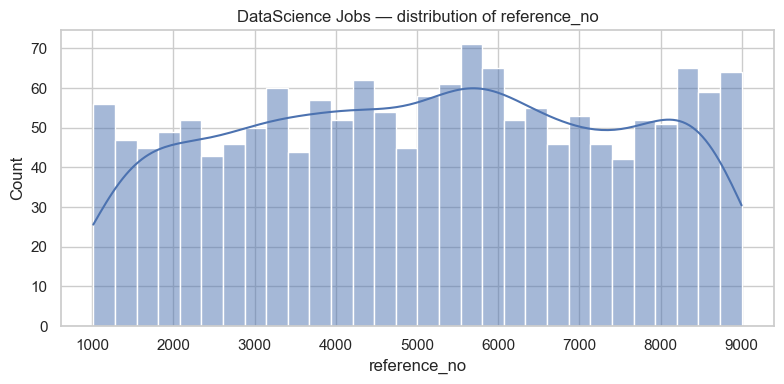

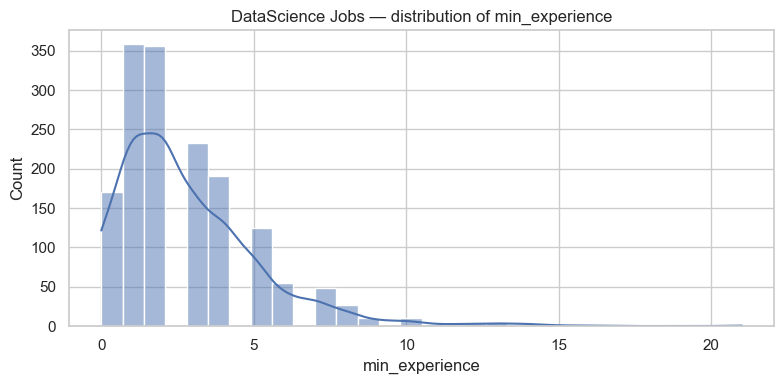

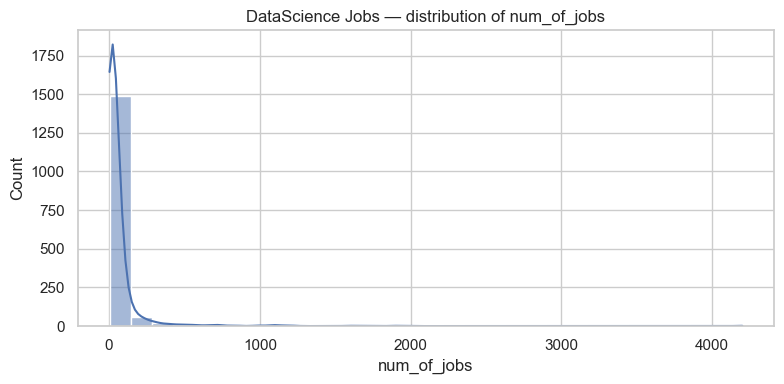

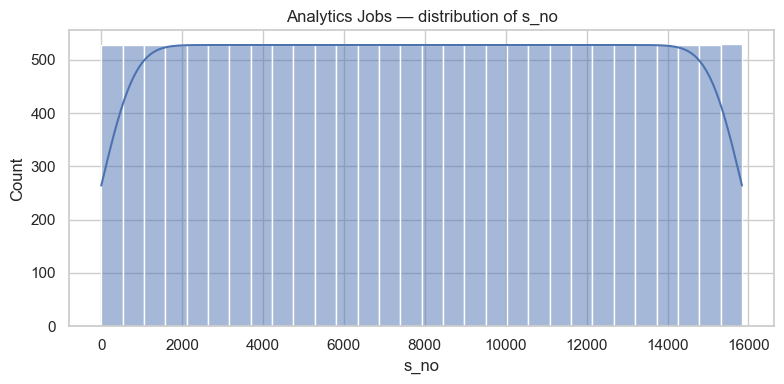

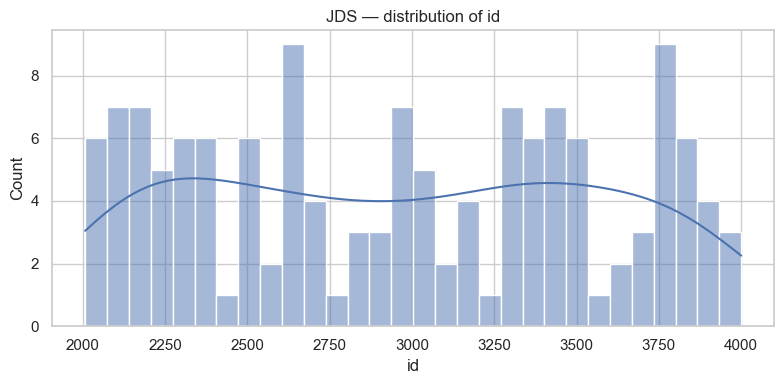

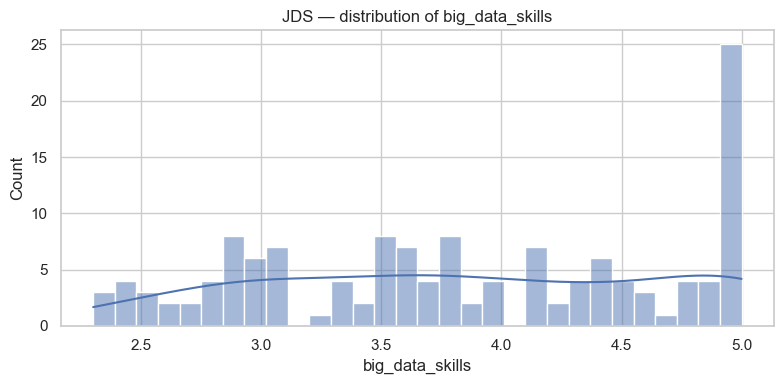

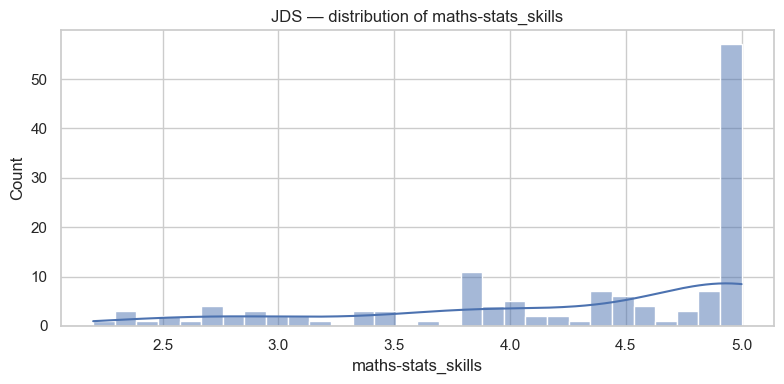

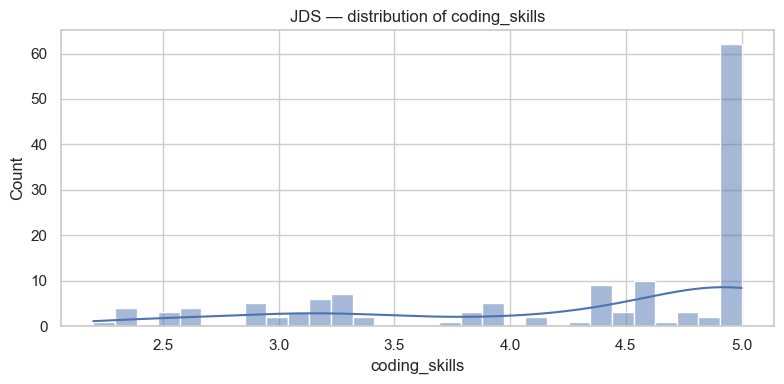

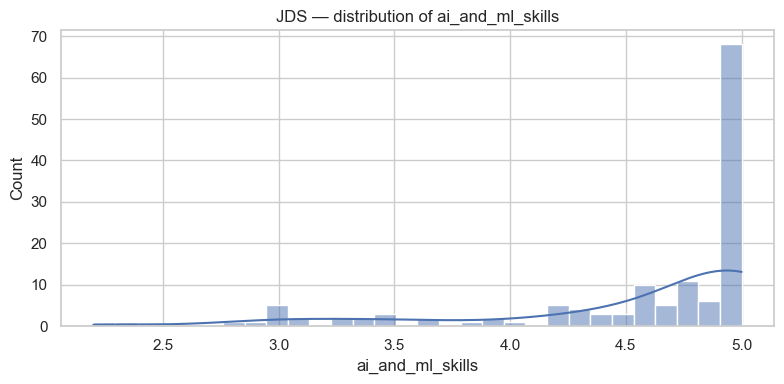

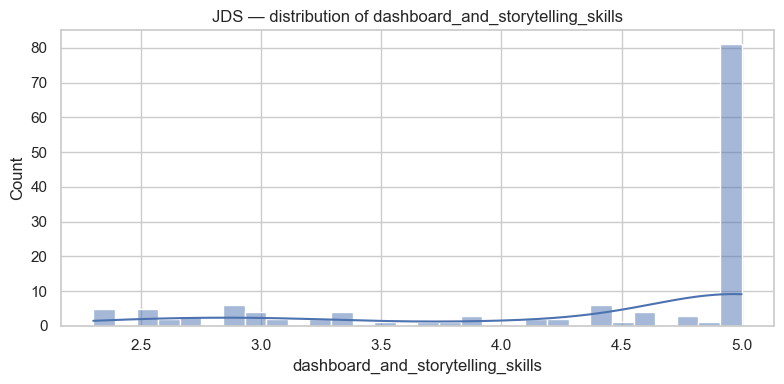

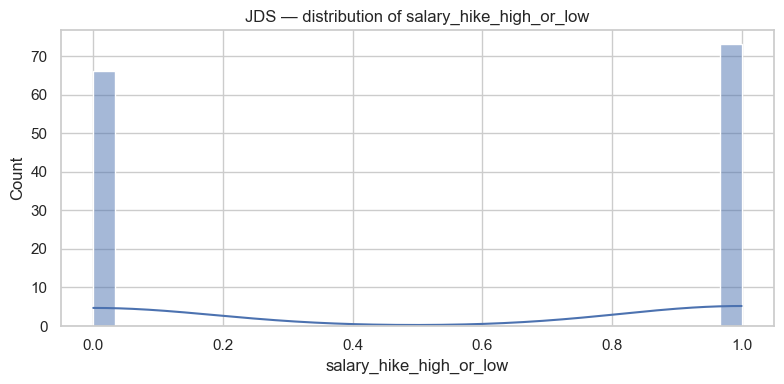

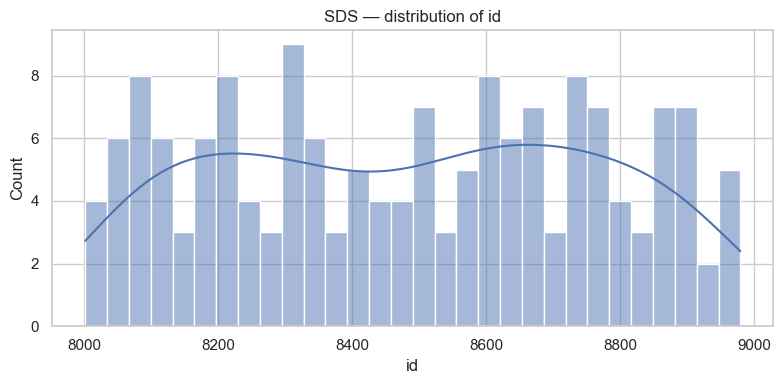

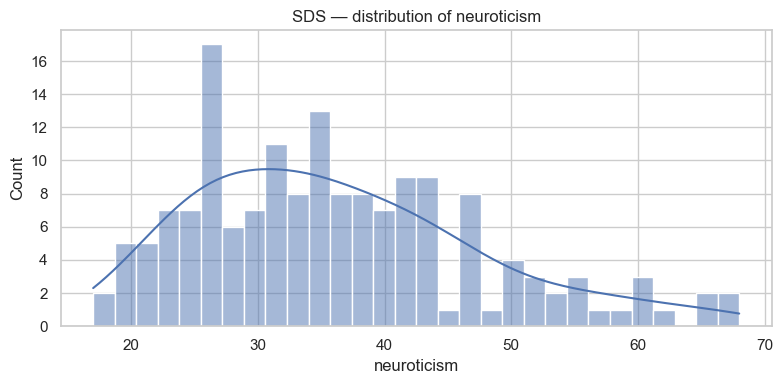

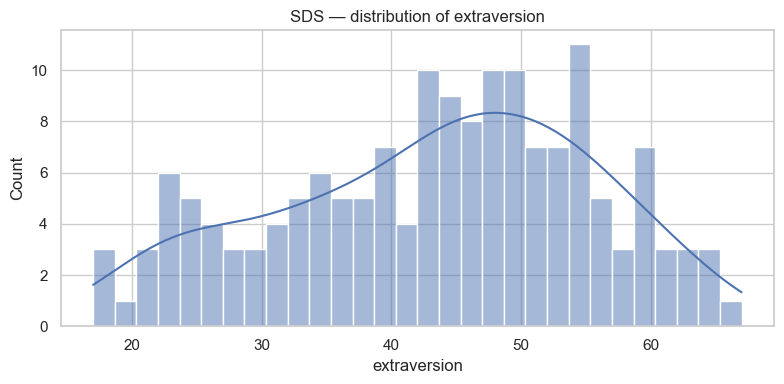

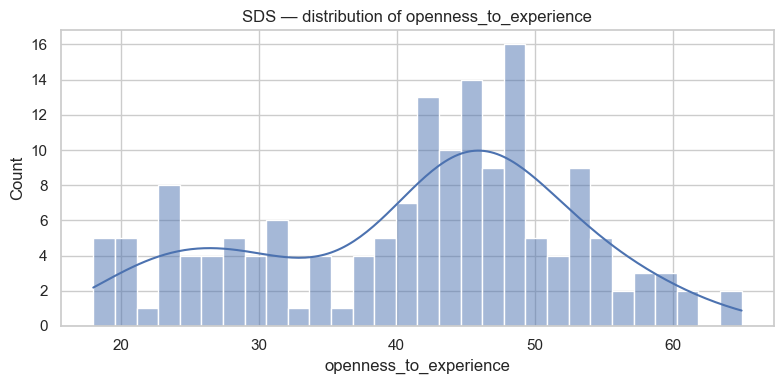

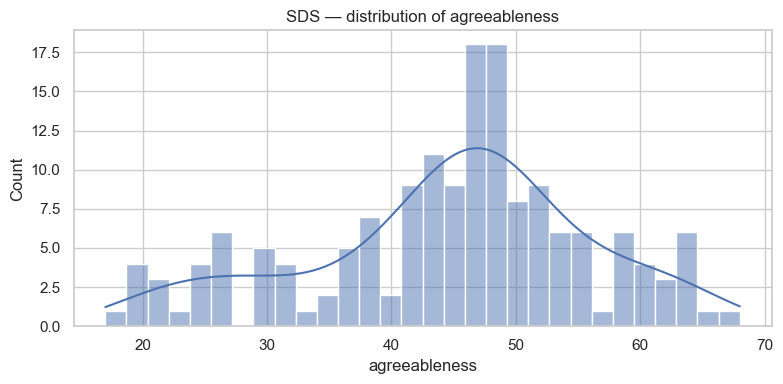

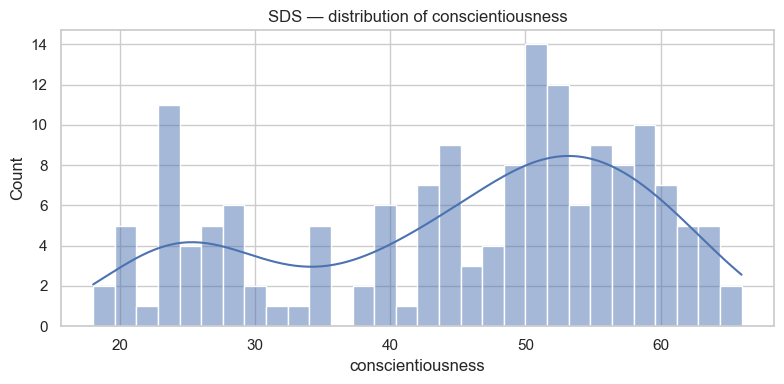

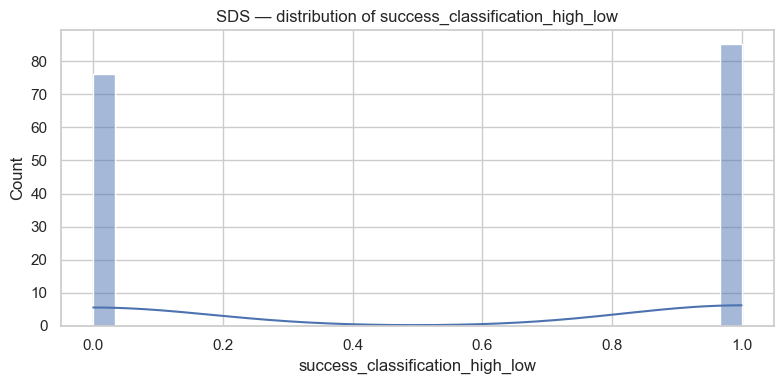

In [10]:

# Histograms + KDE for numeric variables

for name, df in datasets:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols[:20]:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f"{name} — distribution of {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


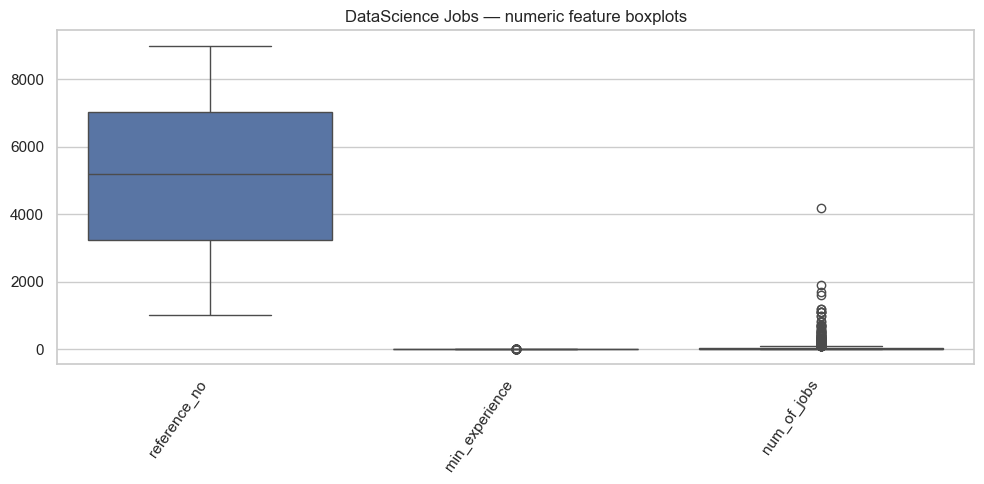

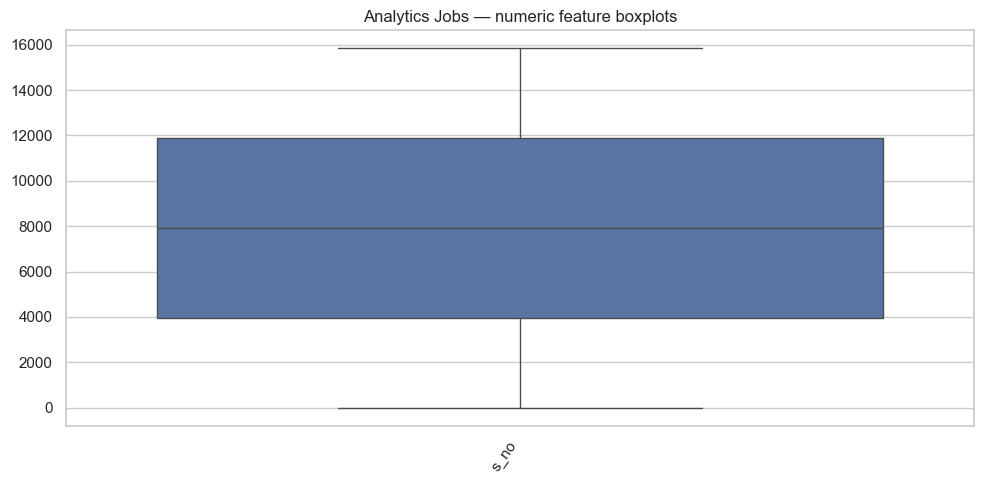

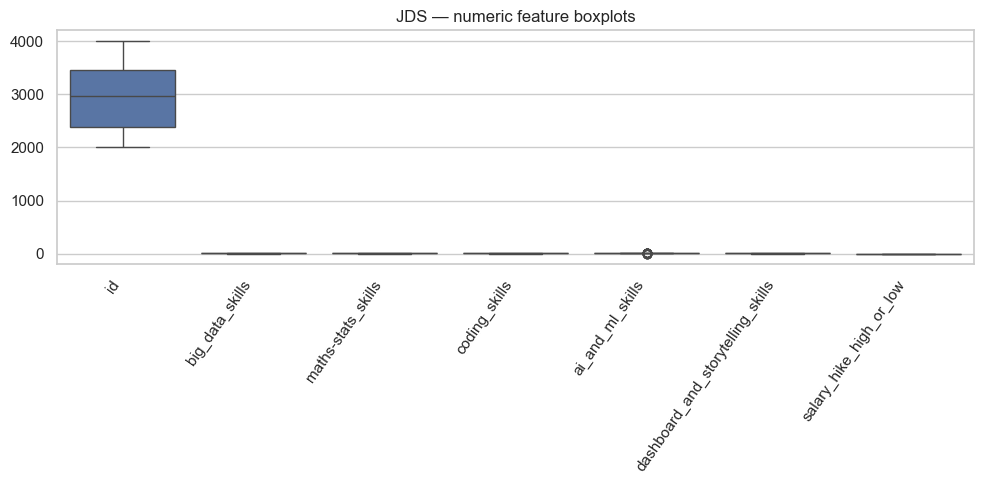

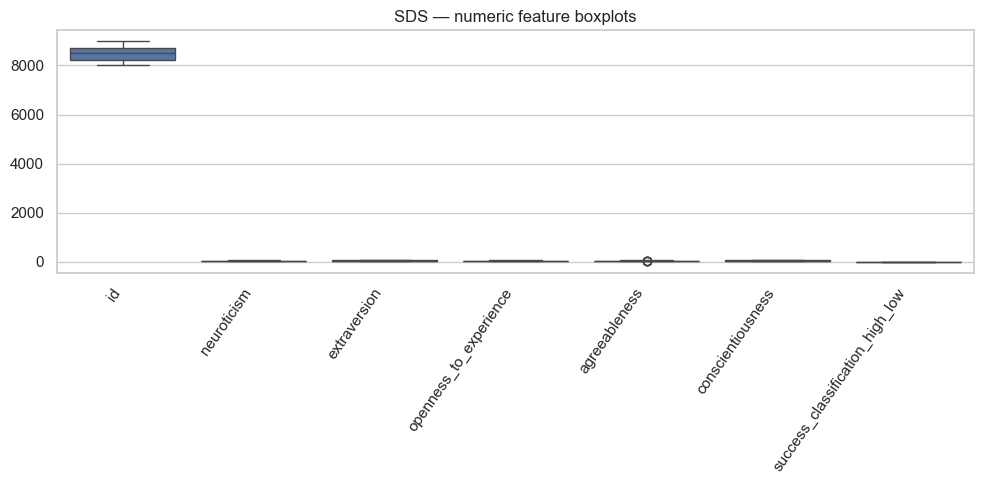

In [11]:

# Boxplots for numeric variables

for name, df in datasets:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if numeric_cols:
        plt.figure(figsize=(max(10, len(numeric_cols)*1.3), 5))
        sns.boxplot(data=df[numeric_cols])
        plt.xticks(rotation=55, ha="right")
        plt.title(f"{name} — numeric feature boxplots")
        plt.tight_layout()
        plt.show()


In [12]:

# Categorical top-frequency analysis

for name, df in datasets:
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n### {name}")
    for col in cat_cols[:15]:
        vc = df[col].astype(str).value_counts(dropna=False).head(10)
        print(f"\n{col} — top categories")
        display(vc.to_frame("count"))



### DataScience Jobs

company_name — top categories


,count
company_name,
TCS,10
Deloitte,10
UST,10
DXC Technology,10
Mindtree,10
Accenture,10
HCL Technologies,10
JP Morgan Chase,10
Tech Mahindra,10



job_title — top categories


,count
job_title,
Data Scientist,188
Business Analyst,188
Data Engineer,188
Data Analyst,187
Senior Business Analyst,187
Senior Data Analyst,187
Senior Data Scientist,185
Senior Data Engineer,183
Machine Learning Engineer,59



avg_salary — top categories


...


location — top categories


,count
location,
Bengaluru,3333
Mumbai,1992
Gurgaon,1313
Pune,945
Hyderabad,878
Chennai,786
Delhi NCR,593
Noida,403
"Delhi NCR, Gurgaon",278



salary — top categories


,count
salary,
10to15,3608
15to25,3281
6to10,2876
0to3,2592
3to6,2239
25to50,1245



### JDS

### SDS


# 8. JDS — Junior Skill Traits

In [13]:

# Resolve JDS target and skill columns

JDS_TARGET = next((c for c in jds.columns if "salary" in c and "hike" in c), None)
if JDS_TARGET is None:
    raise KeyError("Could not identify JDS salary-hike target.")

JDS_SKILLS = [
    c for c in jds.columns
    if any(k in c for k in ["big_data", "math", "stats", "coding", "ai", "ml", "dashboard", "storytelling"])
]

print("Target:", JDS_TARGET)
print("Skill columns:", JDS_SKILLS)

display(jds[JDS_TARGET].value_counts(dropna=False).to_frame("count"))


Target: salary_hike_high_or_low
Skill columns: ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']


,count
salary_hike_high_or_low,
1,73
0,66


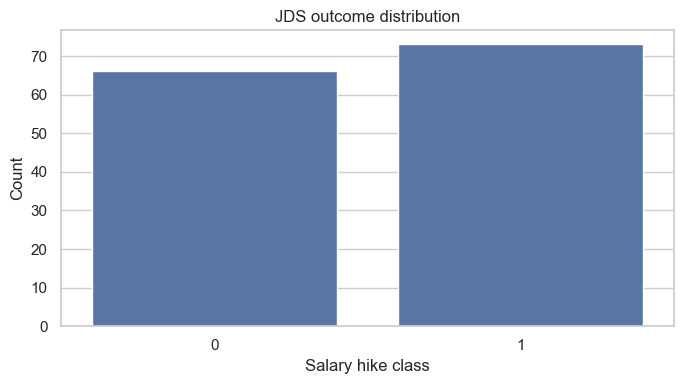

Majority-class baseline accuracy: 52.52%


In [14]:

# JDS target balance

plt.figure(figsize=(7,4))
sns.countplot(data=jds, x=JDS_TARGET)
plt.title("JDS outcome distribution")
plt.xlabel("Salary hike class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

baseline = jds[JDS_TARGET].value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline:.2%}")


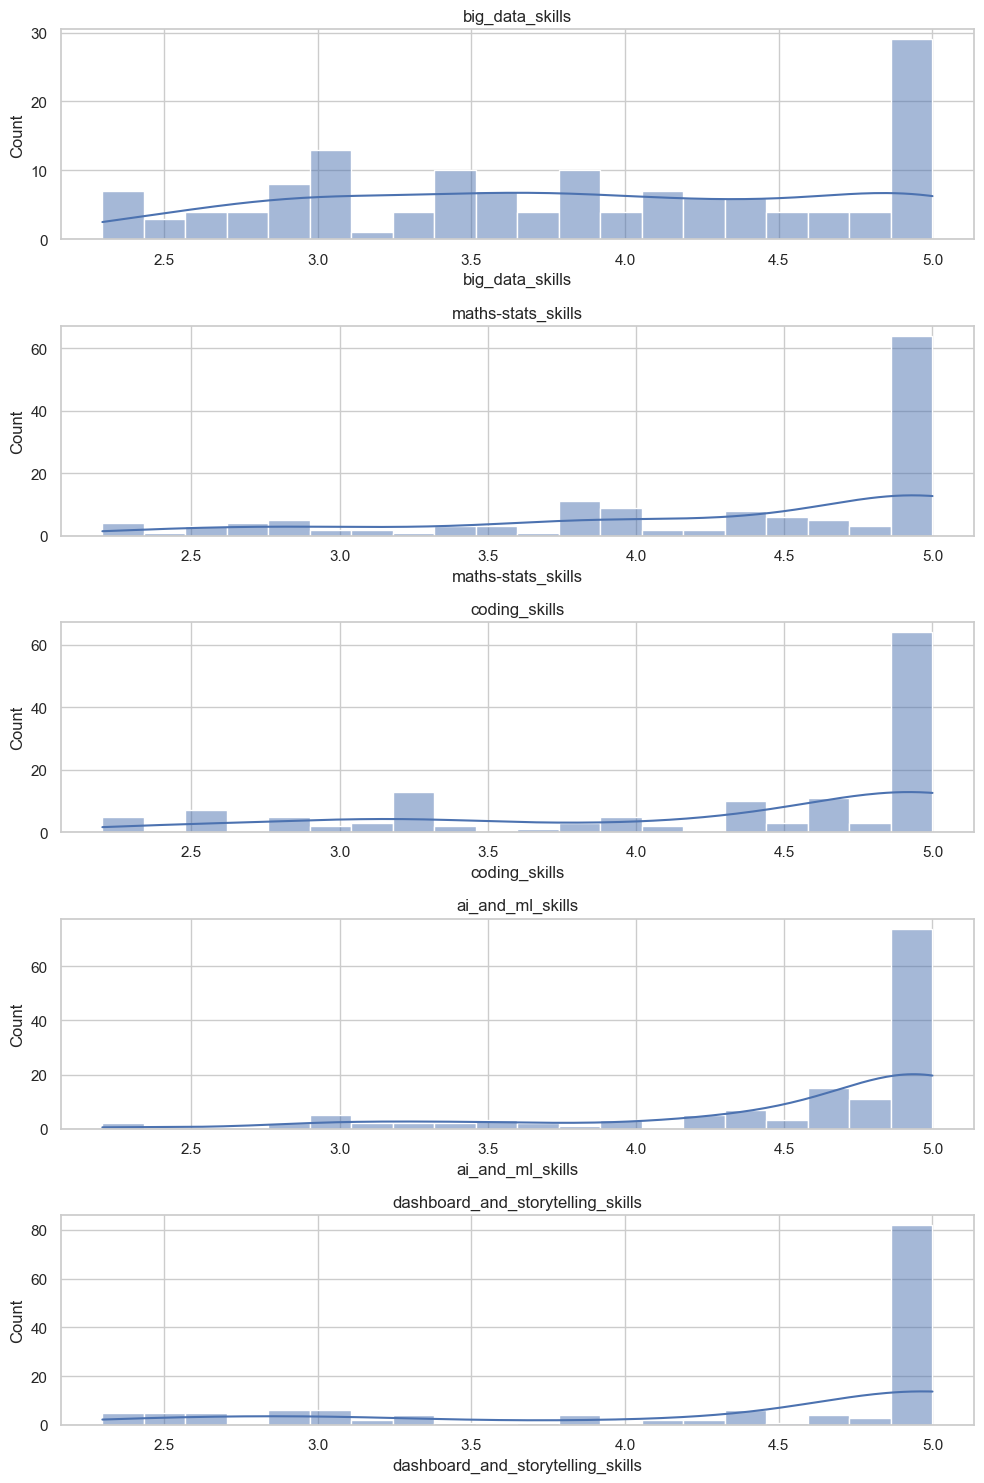

In [15]:

# JDS skill distributions

if JDS_SKILLS:
    fig, axes = plt.subplots(len(JDS_SKILLS), 1, figsize=(10, 3*len(JDS_SKILLS)))
    if len(JDS_SKILLS) == 1:
        axes = [axes]
    for ax, col in zip(axes, JDS_SKILLS):
        sns.histplot(jds[col].dropna(), kde=True, bins=20, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()


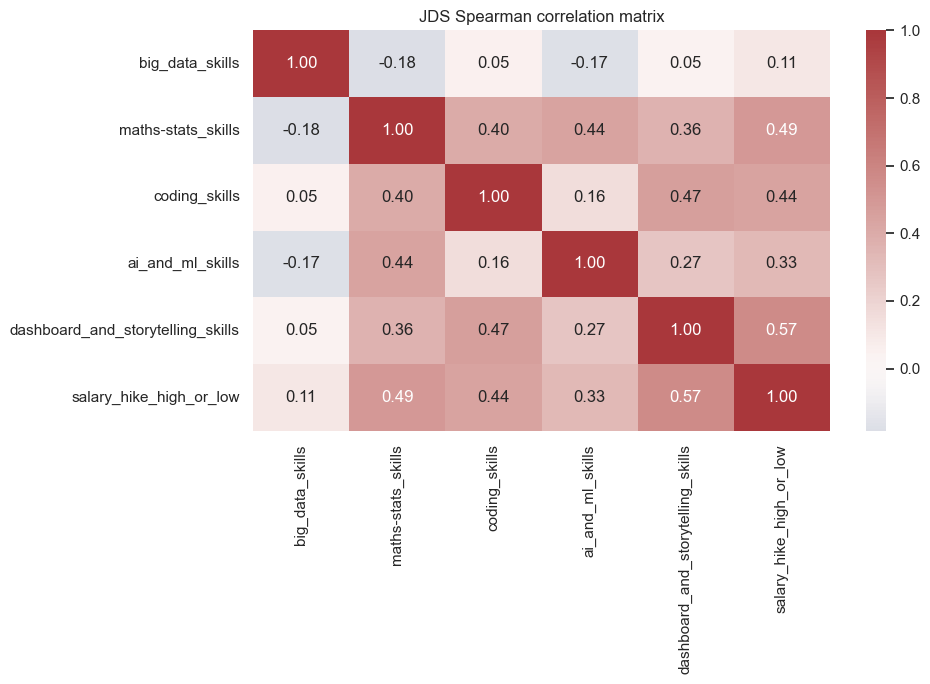

In [16]:

# JDS correlation heatmap

jds_num = jds[JDS_SKILLS + [JDS_TARGET]].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(10,7))
sns.heatmap(jds_num.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("JDS Spearman correlation matrix")
plt.tight_layout()
plt.show()


In [17]:

# JDS skill vs outcome: distribution + effect size

y_jds = jds[JDS_TARGET]
classes = list(y_jds.dropna().unique())

jds_effects = []

for col in JDS_SKILLS:
    tmp = pd.DataFrame({"x": pd.to_numeric(jds[col], errors="coerce"), "y": y_jds}).dropna()
    groups = [g["x"].values for _, g in tmp.groupby("y")]
    if len(groups) == 2:
        a, b = groups[0], groups[1]
        t, p = stats.ttest_ind(a, b, equal_var=False)
        pooled = np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
        d = (a.mean()-b.mean())/pooled if pooled else np.nan
        jds_effects.append([col, len(a), len(b), a.mean(), b.mean(), t, p, d])

jds_effects = pd.DataFrame(jds_effects, columns=[
    "feature","n_class1","n_class2","mean_class1","mean_class2","t_stat","p_value","cohens_d"
])

if len(jds_effects):
    jds_effects["p_fdr"] = multipletests(jds_effects["p_value"], method="fdr_bh")[1]
display(jds_effects.sort_values("p_value"))


,feature,n_class1,n_class2,mean_class1,mean_class2,t_stat,p_value,cohens_d,p_fdr
4,dashboard_and_storytelling_skills,66,73,3.8136,4.8452,-7.5504,0.0000,-1.3233,0.0000
1,maths-stats_skills,66,73,3.8303,4.7123,-6.9597,0.0000,-1.2225,0.0000
2,coding_skills,66,73,3.8530,4.6438,-5.6977,0.0000,-0.9847,0.0000
3,ai_and_ml_skills,66,73,4.2833,4.8219,-4.9885,0.0000,-0.8797,0.0000
0,big_data_skills,66,73,3.7500,3.9397,-1.3031,0.1951,-0.2247,0.1951


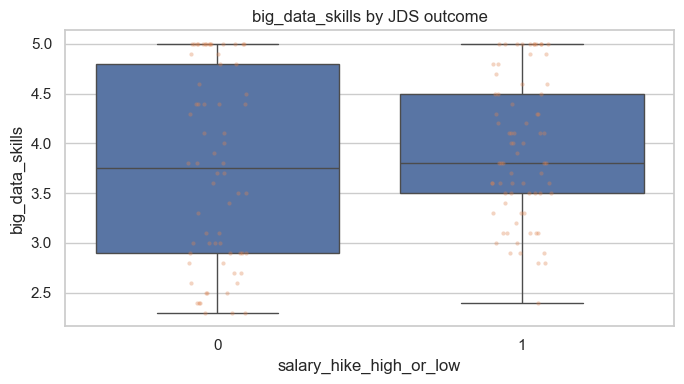

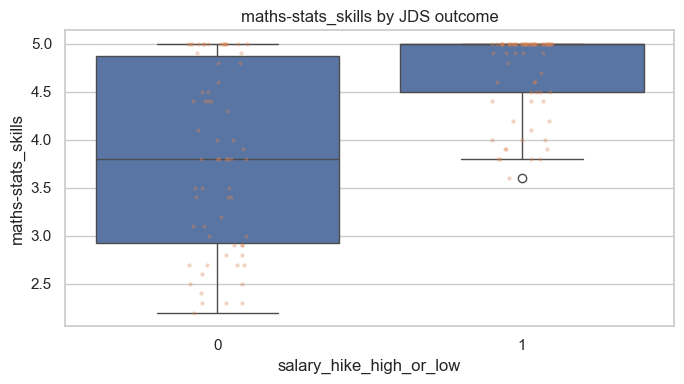

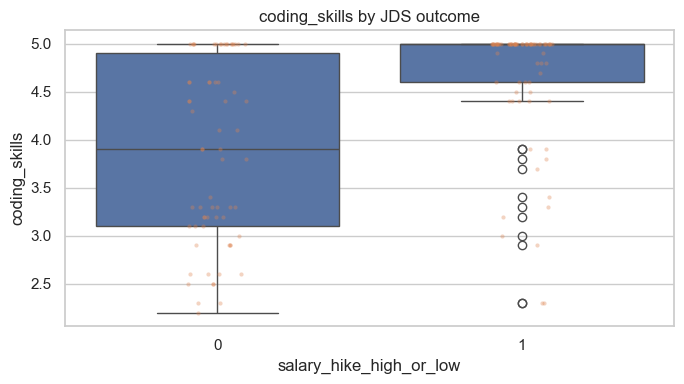

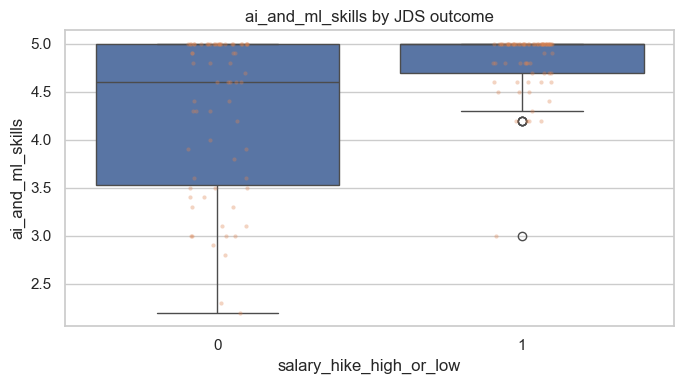

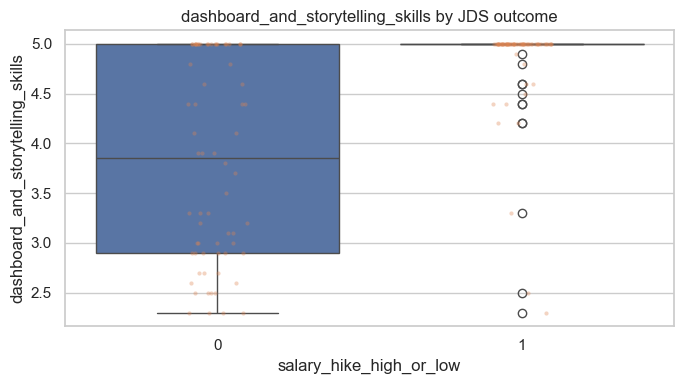

In [18]:

# JDS boxplots by outcome

for col in JDS_SKILLS:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=jds, x=JDS_TARGET, y=col)
    sns.stripplot(data=jds, x=JDS_TARGET, y=col, alpha=.35, size=3)
    plt.title(f"{col} by JDS outcome")
    plt.tight_layout()
    plt.show()


# 9. SDS — Senior Personality Traits

In [19]:

SDS_TARGET = next((c for c in sds.columns if "success" in c and ("high" in c or "low" in c)), None)

SDS_TRAITS = [
    c for c in [
        "neuroticism",
        "extraversion",
        "openness_to_experience",
        "agreeableness",
        "conscientiousness"
    ] if c in sds.columns
]

print("Target:", SDS_TARGET)
print("Traits:", SDS_TRAITS)

display(sds[SDS_TARGET].value_counts(dropna=False).to_frame("count"))


Target: success_classification_high_low
Traits: ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']


,count
success_classification_high_low,
1,85
0,76


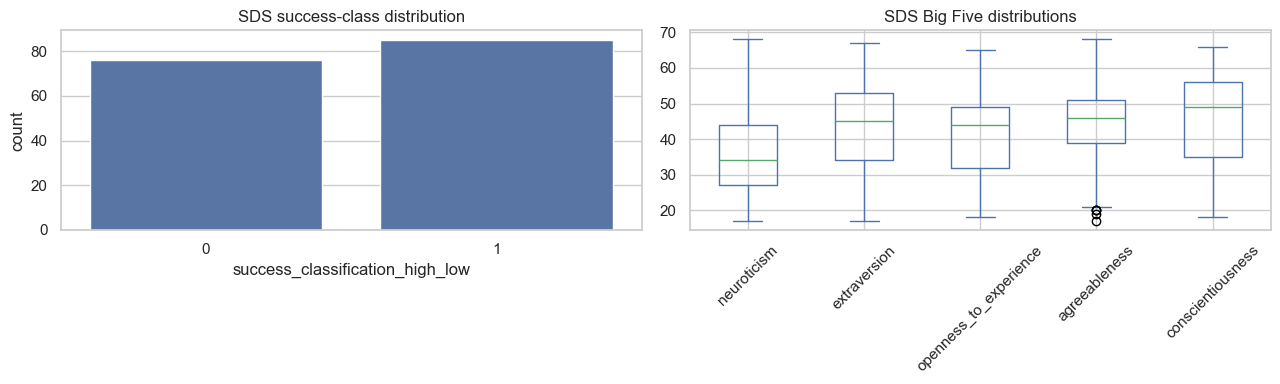

In [20]:

# SDS target and trait distributions

fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.countplot(data=sds, x=SDS_TARGET, ax=axes[0])
axes[0].set_title("SDS success-class distribution")

sds[SDS_TRAITS].plot(kind="box", ax=axes[1])
axes[1].set_title("SDS Big Five distributions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


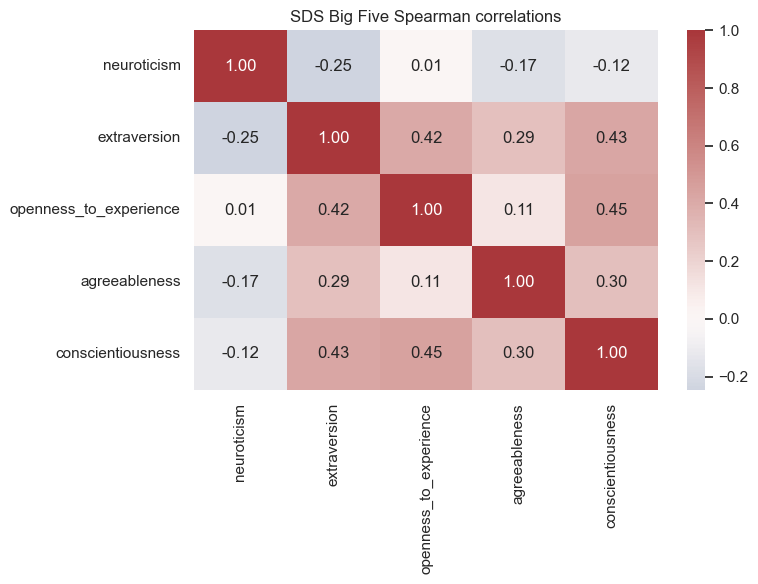

In [21]:

# SDS correlation heatmap

sds_num = sds[SDS_TRAITS].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(8,6))
sns.heatmap(sds_num.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("SDS Big Five Spearman correlations")
plt.tight_layout()
plt.show()


In [22]:

# SDS trait vs outcome effect sizes

sds_effects = []

for col in SDS_TRAITS:
    tmp = pd.DataFrame({"x": pd.to_numeric(sds[col], errors="coerce"), "y": sds[SDS_TARGET]}).dropna()
    groups = [g["x"].values for _, g in tmp.groupby("y")]
    if len(groups) == 2:
        a, b = groups[0], groups[1]
        t, p = stats.ttest_ind(a, b, equal_var=False)
        pooled = np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
        d = (a.mean()-b.mean())/pooled if pooled else np.nan
        sds_effects.append([col, len(a), len(b), a.mean(), b.mean(), t, p, d])

sds_effects = pd.DataFrame(sds_effects, columns=[
    "trait","n_class1","n_class2","mean_class1","mean_class2","t_stat","p_value","cohens_d"
])
sds_effects["p_fdr"] = multipletests(sds_effects["p_value"], method="fdr_bh")[1]
display(sds_effects.sort_values("p_value"))


,trait,n_class1,n_class2,mean_class1,mean_class2,t_stat,p_value,cohens_d,p_fdr
4,conscientiousness,76,85,35.7368,53.6824,-11.2998,0.0000,-1.8472,0.0000
2,openness_to_experience,76,85,33.3158,48.4941,-11.0676,0.0000,-1.8030,0.0000
1,extraversion,76,85,36.8816,48.8588,-6.9643,0.0000,-1.1319,0.0000
3,agreeableness,76,85,41.1184,47.7176,-3.6887,0.0004,-0.6092,0.0005
0,neuroticism,76,85,36.2632,36.1294,0.0735,0.9415,0.0118,0.9415


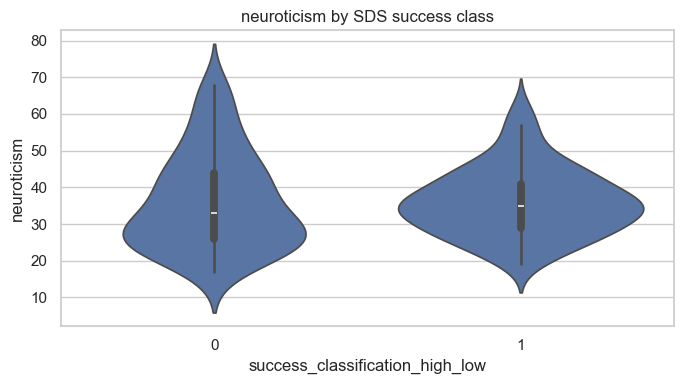

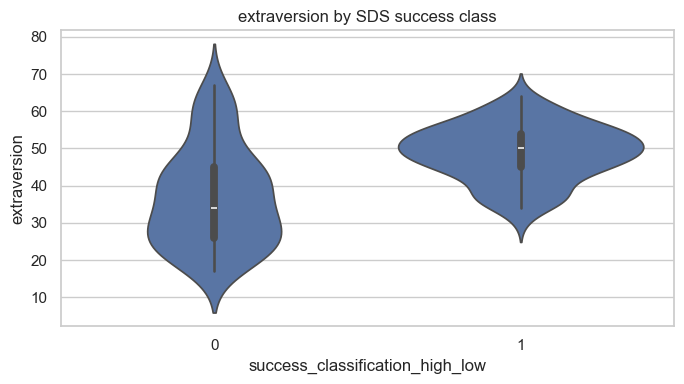

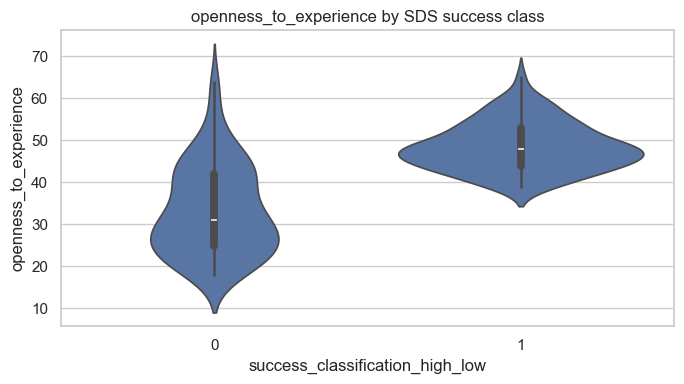

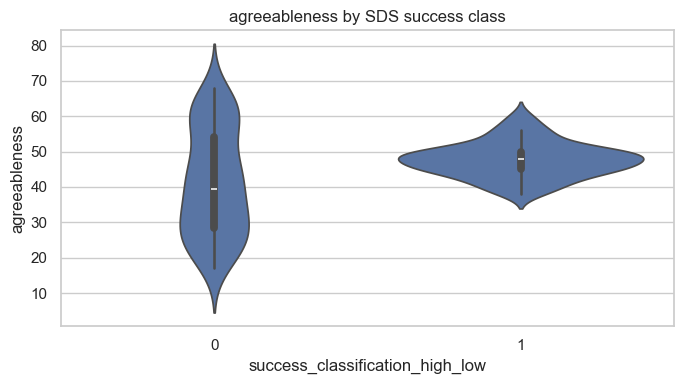

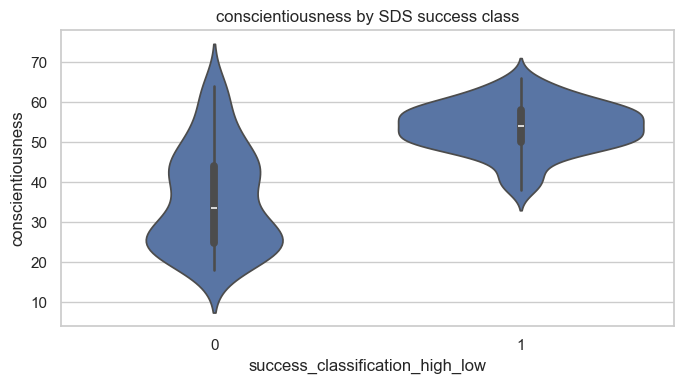

In [23]:

# SDS trait separation plots

for col in SDS_TRAITS:
    plt.figure(figsize=(7,4))
    sns.violinplot(data=sds, x=SDS_TARGET, y=col, inner="box")
    plt.title(f"{col} by SDS success class")
    plt.tight_layout()
    plt.show()


# 10. Market EDA — Data Science Jobs

In [24]:

# Helpers for market datasets

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

salary_cols = {
    "min": first_existing(ds_jobs, ["min_salary", "minimum_salary"]),
    "avg": first_existing(ds_jobs, ["avg_salary", "average_salary", "salary"]),
    "max": first_existing(ds_jobs, ["max_salary", "maximum_salary"]),
}

print("Salary columns:", salary_cols)

for k, c in salary_cols.items():
    if c:
        ds_jobs[c] = pd.to_numeric(ds_jobs[c], errors="coerce")

display(ds_jobs[list(salary_cols.values())].describe().T)


Salary columns: {'min': 'min_salary', 'avg': 'avg_salary', 'max': 'max_salary'}


,count,mean,std,min,25%,50%,75%,max
min_salary,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_salary,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_salary,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:

# Identify likely market categorical fields

for candidates in [
    ["job_title", "title", "role"],
    ["company", "company_name"],
    ["location", "job_location", "city"],
    ["experience", "experience_required"]
]:
    print(candidates, "->", first_existing(ds_jobs, candidates))


['job_title', 'title', 'role'] -> job_title
['company', 'company_name'] -> company_name
['location', 'job_location', 'city'] -> None
['experience', 'experience_required'] -> None


In [26]:

# Role-family classification — transparent heuristic

ROLE_PATTERNS = {
    "data scientist": r"data\s*scientist|data\s*science",
    "data analyst": r"data\s*analyst|business\s*analyst",
    "ml/ai": r"machine\s*learning|\bml\b|artificial\s*intelligence|\bai\b",
    "data engineer": r"data\s*engineer|big\s*data",
    "bi/visualization": r"business\s*intelligence|bi\s*developer|tableau|power\s*bi",
    "other": r".*"
}

title_col = first_existing(ds_jobs, ["job_title", "title", "role"])

def role_family(title):
    s = str(title).lower()
    for role, pattern in ROLE_PATTERNS.items():
        if re.search(pattern, s):
            return role
    return "other"

if title_col:
    ds_jobs["role_family"] = ds_jobs[title_col].map(role_family)
    display(ds_jobs["role_family"].value_counts().to_frame("postings"))


,postings
role_family,
data analyst,749
data scientist,373
data engineer,371
ml/ai,59
other,50


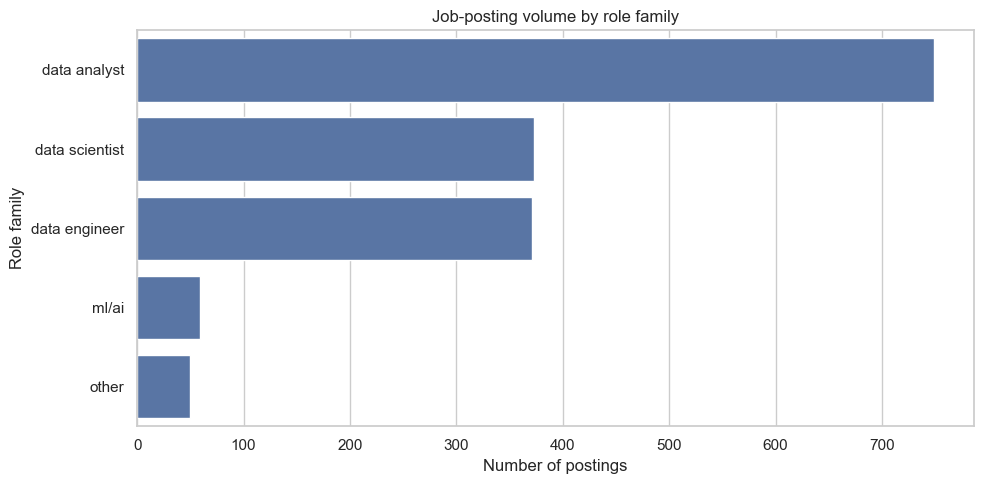

In [27]:

# Role demand chart

if "role_family" in ds_jobs:
    plt.figure(figsize=(10,5))
    order = ds_jobs["role_family"].value_counts().index
    sns.countplot(data=ds_jobs, y="role_family", order=order)
    plt.title("Job-posting volume by role family")
    plt.xlabel("Number of postings")
    plt.ylabel("Role family")
    plt.tight_layout()
    plt.show()


In [58]:
# Advertised Average Salary by Role Family

salary_candidates = [
    c for c in ds_jobs.columns
    if any(k in c.lower() for k in ["salary", "pay", "wage", "compensation"])
]

print("Salary-related columns:", salary_candidates)
print("Current avg_col:", avg_col)

# Try current avg_col first, then other salary-related columns
columns_to_try = [avg_col] + [c for c in salary_candidates if c != avg_col]

chosen_col = None
chosen_values = None

for col in columns_to_try:
    if col not in ds_jobs.columns:
        continue

    def parse_salary(x):
        if pd.isna(x):
            return np.nan

        if isinstance(x, (int, float, np.number)):
            return float(x)

        s = str(x).lower().replace(",", "").strip()

        nums = re.findall(r"\d+(?:\.\d+)?", s)

        if not nums:
            return np.nan

        nums = [float(n) for n in nums]

        # Average range such as 50K-80K
        value = sum(nums) / len(nums)

        # Unit conversion
        if "lpa" in s or "lakh" in s:
            value *= 100000
        elif "k" in s or "thousand" in s:
            value *= 1000

        return value

    parsed = ds_jobs[col].apply(parse_salary)

    if parsed.notna().sum() > 0:
        chosen_col = col
        chosen_values = parsed
        break

if chosen_col is None:
    print("\n❌ No usable salary values found.")
    print("\nSample values from salary columns:")

    for col in salary_candidates:
        print(f"\n{col}:")
        print(ds_jobs[col].dropna().head(10).tolist())

else:
    ds_jobs["_plot_salary"] = chosen_values

    plot_df = ds_jobs[
        ["role_family", "_plot_salary"]
    ].dropna()

    salary_by_role = (
        plot_df
        .groupby("role_family")["_plot_salary"]
        .mean()
        .sort_values(ascending=False)
    )

    print(f"\n✅ Using salary column: {chosen_col}")
    print(f"Usable salary rows: {len(plot_df)}")
    print("\nAverage salary by role:")
    print(salary_by_role.round(2))

    if len(salary_by_role) > 0:

        plt.figure(figsize=(11, 6))

        ax = sns.barplot(
            x=salary_by_role.index,
            y=salary_by_role.values
        )

        plt.xticks(rotation=35, ha="right")
        plt.title("Advertised Average Salary by Role Family")
        plt.xlabel("Role Family")
        plt.ylabel("Average Salary")

        # Add values on bars
        for container in ax.containers:
            ax.bar_label(container, fmt="%.0f", padding=3)

        plt.tight_layout()
        plt.show()

    else:
        print("\n❌ No role/salary combinations available to plot.")

Salary-related columns: ['avg_salary', 'min_salary', 'max_salary', '_salary_clean']
Current avg_col: avg_salary

❌ No usable salary values found.

Sample values from salary columns:

avg_salary:
[]

min_salary:
[]

max_salary:
[]

_salary_clean:
[]


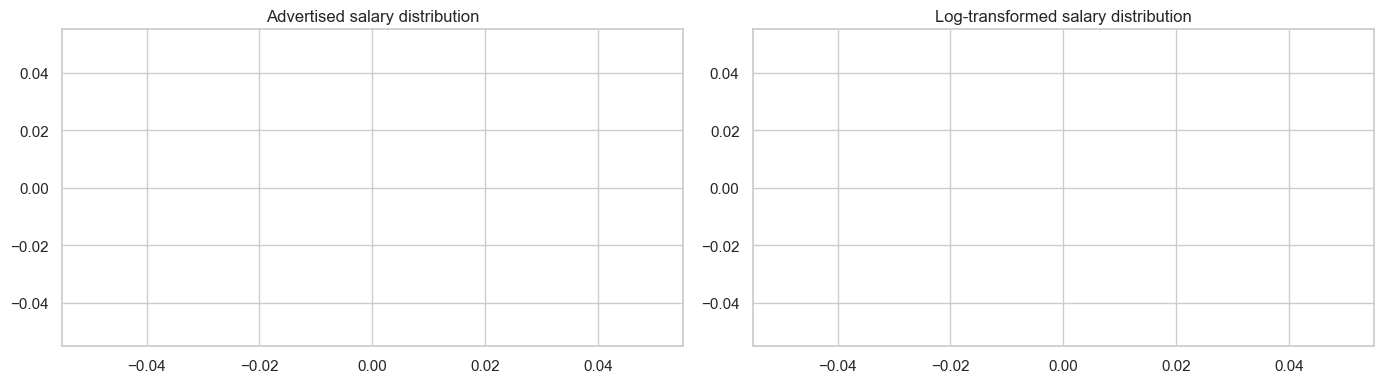

Salary skewness: nan


In [35]:

# Salary distribution + log salary

if avg_col:
    salary = ds_jobs[avg_col].dropna()
    fig, axes = plt.subplots(1,2, figsize=(14,4))
    sns.histplot(salary, kde=True, ax=axes[0])
    axes[0].set_title("Advertised salary distribution")
    sns.histplot(np.log1p(salary), kde=True, ax=axes[1])
    axes[1].set_title("Log-transformed salary distribution")
    plt.tight_layout()
    plt.show()

    print("Salary skewness:", stats.skew(salary))


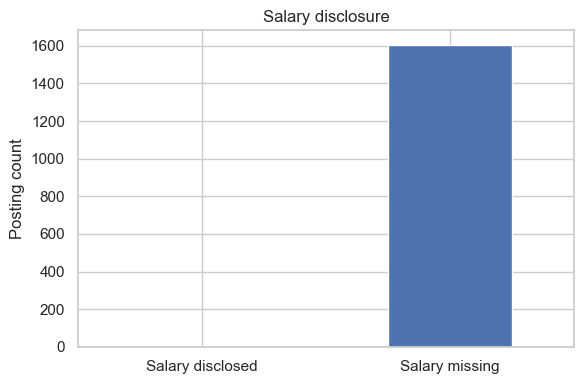

Disclosure rate: 0.00%


In [36]:

# Salary missingness / disclosure

if avg_col:
    disclosure = pd.Series({
        "Salary disclosed": ds_jobs[avg_col].notna().sum(),
        "Salary missing": ds_jobs[avg_col].isna().sum()
    })

    plt.figure(figsize=(6,4))
    disclosure.plot(kind="bar")
    plt.title("Salary disclosure")
    plt.ylabel("Posting count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"Disclosure rate: {ds_jobs[avg_col].notna().mean():.2%}")


In [37]:

# Experience parsing — numeric extraction where possible

exp_col = first_existing(ds_jobs, ["experience", "experience_required", "years_experience"])

if exp_col:
    ds_jobs["experience_numeric"] = (
        ds_jobs[exp_col].astype(str)
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
        .astype(float)
    )

    display(ds_jobs["experience_numeric"].describe().to_frame())


In [38]:

# Experience vs salary

if avg_col and "experience_numeric" in ds_jobs:
    tmp = ds_jobs[[avg_col, "experience_numeric"]].dropna()

    plt.figure(figsize=(9,6))
    sns.scatterplot(data=tmp, x="experience_numeric", y=avg_col, alpha=.35)
    sns.regplot(data=tmp, x="experience_numeric", y=avg_col, scatter=False)
    plt.title("Experience vs advertised average salary")
    plt.xlabel("Experience (parsed years)")
    plt.ylabel("Average advertised salary")
    plt.tight_layout()
    plt.show()

    print("Spearman correlation:",
          tmp["experience_numeric"].corr(tmp[avg_col], method="spearman"))


In [39]:

# Location demand

loc_col = first_existing(ds_jobs, ["location", "job_location", "city"])

if loc_col:
    top_loc = ds_jobs[loc_col].astype(str).value_counts().head(20)
    plt.figure(figsize=(10,7))
    top_loc.sort_values().plot(kind="barh")
    plt.title("Top job-posting locations")
    plt.xlabel("Postings")
    plt.tight_layout()
    plt.show()


## Analytics Jobs — Skill Demand

In [40]:

# H1 role-level descriptive statistics

if avg_col and "role_family" in ds_jobs:
    role_stats = (
        ds_jobs.dropna(subset=[avg_col])
        .groupby("role_family")[avg_col]
        .agg(["count","mean","median","std","min","max"])
        .sort_values("median", ascending=False)
    )
    display(role_stats)


,count,mean,median,std,min,max
role_family,,,,,,


In [41]:

# H1 Kruskal-Wallis + epsilon-squared

if avg_col and "role_family" in ds_jobs:
    groups = [
        g[avg_col].dropna().values
        for _, g in ds_jobs.groupby("role_family")
        if g[avg_col].notna().sum() >= 3
    ]
    role_names = [
        name for name, g in ds_jobs.groupby("role_family")
        if g[avg_col].notna().sum() >= 3
    ]

    if len(groups) >= 2:
        H, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        epsilon_sq = max(0, (H - k + 1) / (n - k))

        print(f"Kruskal-Wallis H = {H:.4f}")
        print(f"p-value = {p:.6g}")
        print(f"Epsilon-squared = {epsilon_sq:.4f}")


In [42]:

# Pairwise role comparisons with FDR correction

if avg_col and "role_family" in ds_jobs:
    role_groups = {
        name: g[avg_col].dropna()
        for name, g in ds_jobs.groupby("role_family")
        if g[avg_col].notna().sum() >= 3
    }

    pairs, pvals = [], []
    names = list(role_groups)

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            a, b = role_groups[names[i]], role_groups[names[j]]
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            pairs.append(f"{names[i]} vs {names[j]}")
            pvals.append(p)

    if pvals:
        reject, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
        pairwise = pd.DataFrame({
            "comparison": pairs,
            "p_value": pvals,
            "p_fdr": p_adj,
            "significant_fdr": reject
        }).sort_values("p_fdr")
        display(pairwise)


# 12. Analytics Jobs — skill demand analysis

In [43]:

# Inspect likely skill-bearing columns

skill_like = [
    c for c in analytics_jobs.columns
    if any(k in c for k in ["skill", "requirement", "description", "keyword"])
]

print("Potential skill columns:")
print(skill_like)


Potential skill columns:
['job_description', 'key_skills']


In [45]:

# Flexible skill-token extraction

def tokenize_skills(series):
    tokens = []
    for value in series.dropna().astype(str):
        parts = re.split(r"[,;|/]+", value.lower())
        tokens.extend([re.sub(r"[^a-z0-9+#.\- ]", "", p).strip() for p in parts])
    return pd.Series([x for x in tokens if x and len(x) > 1])

# Choose a likely skill column; otherwise use all text-like columns.
preferred_skill = next((c for c in skill_like if "skill" in c), None)

if preferred_skill:
    skill_tokens = tokenize_skills(analytics_jobs[preferred_skill])
    skill_counts = skill_tokens.value_counts()
    display(skill_counts.head(30).to_frame("demand"))
else:
    print("No single skill column identified. Inspect `skill_like` and select the appropriate source column.")


,demand
...,961
sql,918
analytics,904
python,841
finance,756
java,732
sas,638
business analysis,633
machine learning,631
data analysis,618


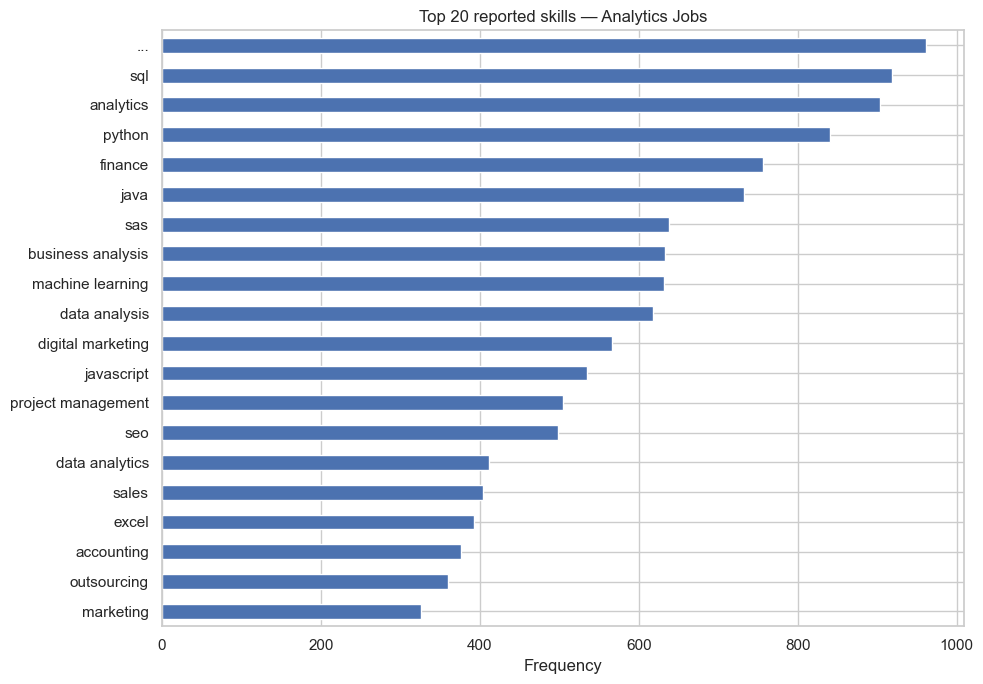

In [46]:

# Top skill demand

if preferred_skill:
    top = skill_counts.head(20).sort_values()
    plt.figure(figsize=(10,7))
    top.plot(kind="barh")
    plt.title("Top 20 reported skills — Analytics Jobs")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()


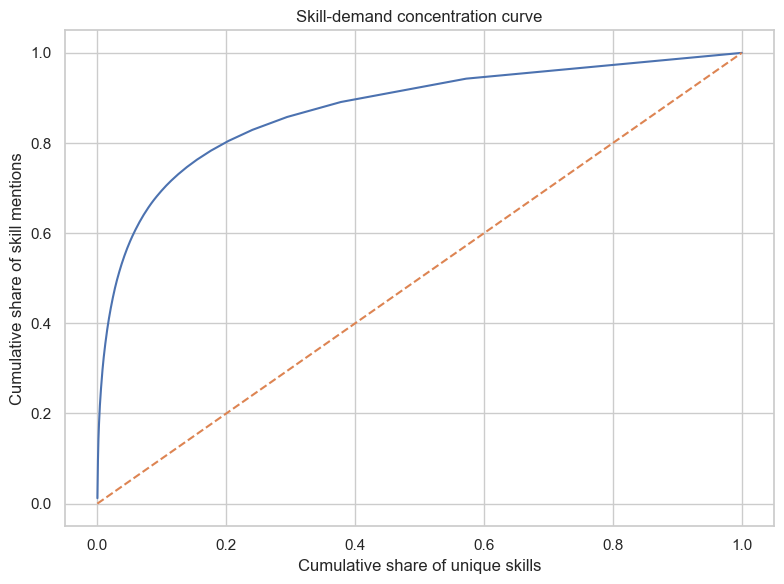

In [47]:

# Skill concentration: Lorenz-style cumulative demand

if preferred_skill:
    vals = np.sort(skill_counts.values)[::-1]
    cumulative = np.cumsum(vals) / vals.sum()
    share = np.arange(1, len(vals)+1) / len(vals)

    plt.figure(figsize=(8,6))
    plt.plot(share, cumulative)
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("Cumulative share of unique skills")
    plt.ylabel("Cumulative share of skill mentions")
    plt.title("Skill-demand concentration curve")
    plt.tight_layout()
    plt.show()


# 13. Skill co-occurrence network

In [48]:

if preferred_skill:
    G = nx.Graph()

    for value in analytics_jobs[preferred_skill].dropna().astype(str):
        toks = sorted(set([
            re.sub(r"[^a-z0-9+#.\- ]", "", p).strip()
            for p in re.split(r"[,;|/]+", value.lower())
            if len(p.strip()) > 1
        ]))
        toks = [t for t in toks if t]

        for t in toks:
            G.add_node(t)

        for i in range(len(toks)):
            for j in range(i+1, len(toks)):
                if G.has_edge(toks[i], toks[j]):
                    G[toks[i]][toks[j]]["weight"] += 1
                else:
                    G.add_edge(toks[i], toks[j], weight=1)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    centrality = pd.DataFrame({
        "skill": list(G.nodes()),
        "degree": [G.degree(n) for n in G.nodes()],
        "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()]
    }).sort_values("weighted_degree", ascending=False)

    display(centrality.head(25))


Nodes: 10591
Edges: 79396


,skill,degree,weighted_degree
225,...,1644,5223
55,sql,999,5003
58,java,821,4520
61,python,763,4466
53,analytics,900,4019
7,javascript,624,3457
90,finance,848,3107
282,sas,499,2868
59,machine learning,392,2650
49,data analysis,682,2529


## Multivariate Analysis

In [49]:

# Generic bootstrap CI for a mean difference

def bootstrap_mean_difference(a, b, B=3000, seed=42):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    diffs = np.empty(B)

    for i in range(B):
        aa = rng.choice(a, len(a), replace=True)
        bb = rng.choice(b, len(b), replace=True)
        diffs[i] = aa.mean() - bb.mean()

    return np.quantile(diffs, [0.025, 0.5, 0.975])

# Example: bootstrap JDS effect estimates

jds_boot = []

for col in JDS_SKILLS:
    tmp = pd.DataFrame({"x": pd.to_numeric(jds[col], errors="coerce"), "y": jds[JDS_TARGET]}).dropna()
    groups = [g["x"].values for _, g in tmp.groupby("y")]
    if len(groups) == 2 and all(len(g) > 5 for g in groups):
        ci = bootstrap_mean_difference(groups[0], groups[1])
        jds_boot.append([col, *ci])

display(pd.DataFrame(jds_boot, columns=["feature","ci_low","bootstrap_median","ci_high"]))


,feature,ci_low,bootstrap_median,ci_high
0,big_data_skills,-0.4835,-0.1953,0.0980
1,maths-stats_skills,-1.1317,-0.8802,-0.6356
2,coding_skills,-1.0716,-0.7934,-0.5217
3,ai_and_ml_skills,-0.7525,-0.5389,-0.3313
4,dashboard_and_storytelling_skills,-1.2984,-1.0334,-0.7594


In [50]:

# Mutual information — JDS skills vs binary outcome

tmp = jds[JDS_SKILLS + [JDS_TARGET]].dropna().copy()
X = tmp[JDS_SKILLS].apply(pd.to_numeric, errors="coerce").fillna(0)
y = pd.factorize(tmp[JDS_TARGET])[0]

mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": JDS_SKILLS, "mutual_information": mi}).sort_values(
    "mutual_information", ascending=False
)

display(mi_df)


,feature,mutual_information
1,maths-stats_skills,0.1586
4,dashboard_and_storytelling_skills,0.1447
2,coding_skills,0.1276
3,ai_and_ml_skills,0.0719
0,big_data_skills,0.0711


Feature: big_data_skills
Observed absolute mean difference: 0.18972602739726074
Permutation p-value: 0.1889622075584883


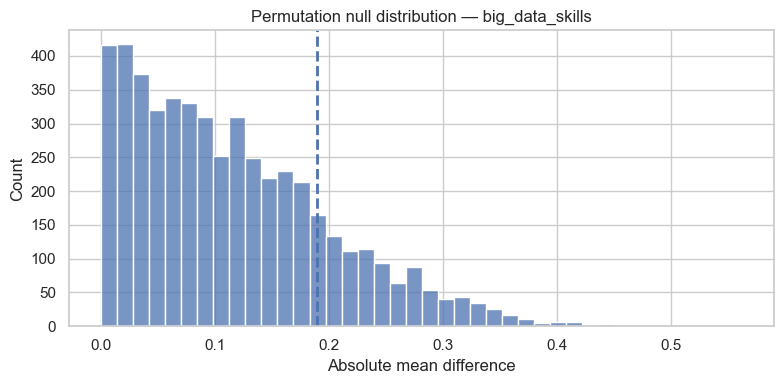

In [51]:

# Permutation test: strongest JDS skill association

if len(JDS_SKILLS):
    feature = JDS_SKILLS[0]
    tmp = pd.DataFrame({
        "x": pd.to_numeric(jds[feature], errors="coerce"),
        "y": jds[JDS_TARGET]
    }).dropna()

    classes = tmp["y"].unique()
    if len(classes) == 2:
        a = tmp.loc[tmp["y"] == classes[0], "x"].values
        b = tmp.loc[tmp["y"] == classes[1], "x"].values
        observed = abs(a.mean() - b.mean())

        rng = np.random.default_rng(42)
        pooled = np.concatenate([a,b])
        n_a = len(a)
        null = []

        for _ in range(5000):
            perm = rng.permutation(pooled)
            null.append(abs(perm[:n_a].mean() - perm[n_a:].mean()))

        p_perm = (np.sum(np.asarray(null) >= observed) + 1) / (len(null) + 1)

        print("Feature:", feature)
        print("Observed absolute mean difference:", observed)
        print("Permutation p-value:", p_perm)

        plt.figure(figsize=(8,4))
        sns.histplot(null, bins=40)
        plt.axvline(observed, linestyle="--", linewidth=2)
        plt.title(f"Permutation null distribution — {feature}")
        plt.xlabel("Absolute mean difference")
        plt.tight_layout()
        plt.show()


# 15. Multivariate exploratory analysis

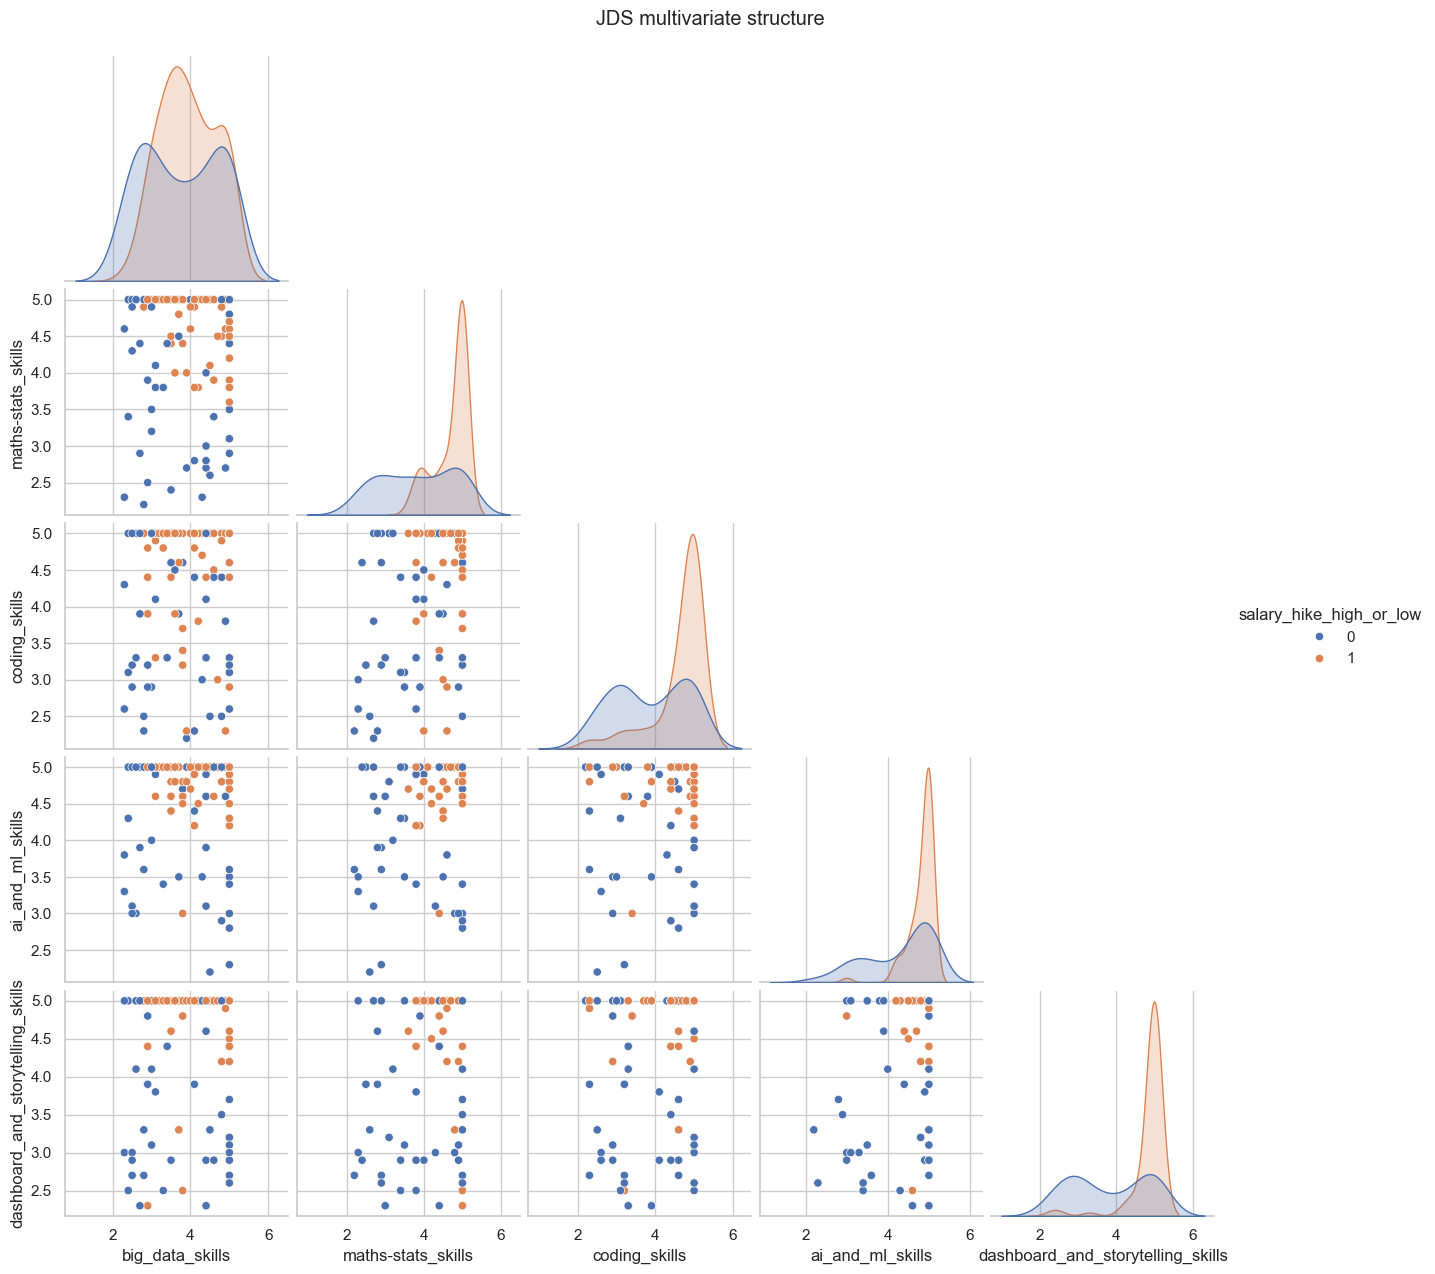

In [52]:

# JDS pairplot

if len(JDS_SKILLS) >= 2:
    cols = JDS_SKILLS[:5] + [JDS_TARGET]
    sns.pairplot(jds[cols].dropna(), hue=JDS_TARGET, corner=True, diag_kind="kde")
    plt.suptitle("JDS multivariate structure", y=1.02)
    plt.show()


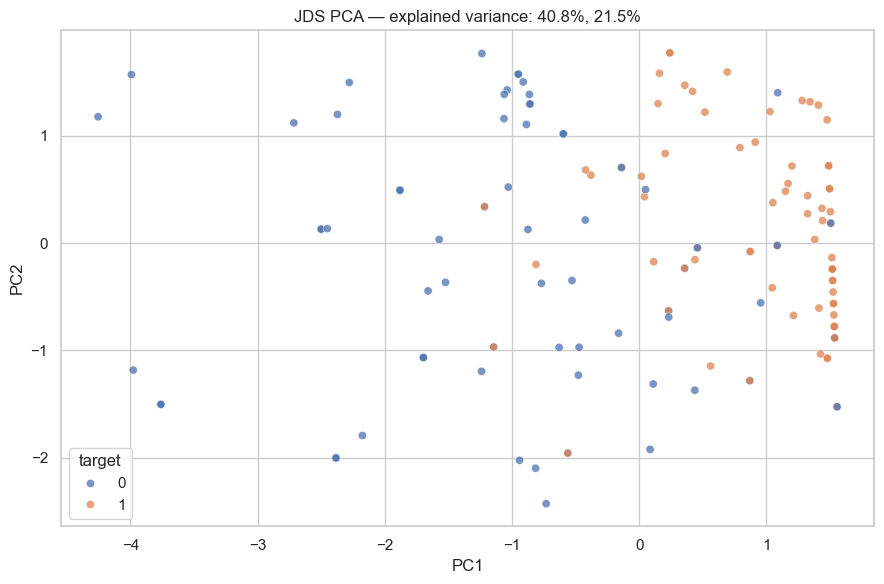

PCA loadings:


,PC1,PC2
big_data_skills,-0.0262,0.9026
maths-stats_skills,0.5403,-0.2058
coding_skills,0.5092,0.1931
ai_and_ml_skills,0.4377,-0.2069
dashboard_and_storytelling_skills,0.5065,0.2509


In [53]:

# PCA visualization for JDS skills

from sklearn.decomposition import PCA

tmp = jds[JDS_SKILLS + [JDS_TARGET]].dropna().copy()

if len(tmp) > 5 and len(JDS_SKILLS) >= 2:
    X = StandardScaler().fit_transform(tmp[JDS_SKILLS].astype(float))
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)

    pca_df = pd.DataFrame({"PC1": Z[:,0], "PC2": Z[:,1], "target": tmp[JDS_TARGET].values})

    plt.figure(figsize=(9,6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target", alpha=.75)
    plt.title(
        f"JDS PCA — explained variance: "
        f"{pca.explained_variance_ratio_[0]:.1%}, {pca.explained_variance_ratio_[1]:.1%}"
    )
    plt.tight_layout()
    plt.show()

    print("PCA loadings:")
    loadings = pd.DataFrame(
        pca.components_.T,
        index=JDS_SKILLS,
        columns=["PC1","PC2"]
    )
    display(loadings)


# 16. H3-style market salary analysis

In [54]:

# Create broad technical / communication proxies if Analytics Jobs has suitable skill text.
# This is deliberately a baseline exploratory mapping, not the final ~300-skill ontology.

TEXT_COLS = [c for c in analytics_jobs.columns if analytics_jobs[c].dtype == "object"]

def contains_any(row_text, patterns):
    s = str(row_text).lower()
    return int(any(re.search(p, s) for p in patterns))

TECH_PATTERNS = [
    r"python", r"sql", r"r\b", r"machine learning", r"deep learning",
    r"statistics", r"tensorflow", r"pytorch", r"java", r"c\+\+"
]

COMM_PATTERNS = [
    r"communication", r"storytelling", r"presentation",
    r"stakeholder", r"business communication", r"visualization"
]

if TEXT_COLS:
    text_blob = analytics_jobs[TEXT_COLS].fillna("").astype(str).agg(" ".join, axis=1)
    analytics_jobs["technical_signal"] = text_blob.map(lambda x: contains_any(x, TECH_PATTERNS))
    analytics_jobs["communication_signal"] = text_blob.map(lambda x: contains_any(x, COMM_PATTERNS))

    print("Technical signal prevalence:", analytics_jobs["technical_signal"].mean())
    print("Communication signal prevalence:", analytics_jobs["communication_signal"].mean())


Technical signal prevalence: 0.865096900448204
Communication signal prevalence: 0.07966668770910927


## Presentation Takeaways

Use the outputs above to explain **what we found, how strong the evidence is, and what should be investigated next**.

In [55]:

# Static evidence already observed in earlier analysis, shown transparently.
# These values are preliminary historical findings and should be revalidated above.

static_findings = pd.DataFrame([
    ["JDS", "Target distribution", "salary_hike_high_or_low approximately 73/66", "Descriptive", "Preliminary"],
    ["JDS", "Skill association", "dashboard/storytelling showed the strongest preliminary correlation (~0.554)", "Spearman/correlation", "Preliminary"],
    ["JDS", "Skill association", "maths/stats (~0.524), coding (~0.444), AI/ML (~0.405)", "Spearman/correlation", "Preliminary"],
    ["JDS", "Big Data", "weaker preliminary correlation (~0.112)", "Spearman/correlation", "Preliminary"],
    ["SDS", "Trait association", "conscientiousness (~0.680) and openness (~0.671) were strongest preliminary correlations", "Spearman/correlation", "Forensic review required"],
    ["SDS", "Trait association", "neuroticism was near zero (~-0.006)", "Spearman/correlation", "Preliminary"],
    ["SDS", "Predictive warning", "preliminary XGBoost AUC was ~0.995", "Modeling result", "Forensic warning — not a final claim"],
], columns=["dataset","finding_type","finding","method","status"])

display(static_findings)


,dataset,finding_type,finding,method,status
0,JDS,Target distribution,salary_hike_high_or_low approximately 73/66,Descriptive,Preliminary
1,JDS,Skill association,dashboard/storytelling showed the strongest pr...,Spearman/correlation,Preliminary
2,JDS,Skill association,"maths/stats (~0.524), coding (~0.444), AI/ML (...",Spearman/correlation,Preliminary
3,JDS,Big Data,weaker preliminary correlation (~0.112),Spearman/correlation,Preliminary
4,SDS,Trait association,conscientiousness (~0.680) and openness (~0.67...,Spearman/correlation,Forensic review required
5,SDS,Trait association,neuroticism was near zero (~-0.006),Spearman/correlation,Preliminary
6,SDS,Predictive warning,preliminary XGBoost AUC was ~0.995,Modeling result,Forensic warning — not a final claim


In [56]:

# Automatically generate a compact analysis checklist

checklist = pd.DataFrame([
    ["Data quality audit", True, "Missingness, duplicates, types and ranges inspected"],
    ["JDS univariate EDA", True, "Skill distributions and target balance"],
    ["SDS univariate EDA", True, "Big Five distributions and target balance"],
    ["Market salary EDA", avg_col is not None, "Salary distribution, role comparison, disclosure"],
    ["Experience-salary analysis", "experience_numeric" in ds_jobs, "Scatter + Spearman"],
    ["H1 statistical test", avg_col is not None and "role_family" in ds_jobs, "Kruskal-Wallis + effect size"],
    ["Skill demand EDA", preferred_skill is not None, "Frequency + concentration"],
    ["Skill network", preferred_skill is not None, "Co-occurrence structure"],
    ["Bootstrap analysis", len(jds_boot) > 0, "95% bootstrap intervals"],
    ["Mutual information", len(mi_df) > 0, "Nonlinear association"],
    ["Permutation test", True, "Null-distribution inference"],
    ["PCA", len(JDS_SKILLS) >= 2, "Exploratory multivariate structure"],
], columns=["analysis","completed","purpose"])

display(checklist)


,analysis,completed,purpose
0,Data quality audit,True,"Missingness, duplicates, types and ranges insp..."
1,JDS univariate EDA,True,Skill distributions and target balance
2,SDS univariate EDA,True,Big Five distributions and target balance
3,Market salary EDA,True,"Salary distribution, role comparison, disclosure"
4,Experience-salary analysis,False,Scatter + Spearman
5,H1 statistical test,True,Kruskal-Wallis + effect size
6,Skill demand EDA,True,Frequency + concentration
7,Skill network,True,Co-occurrence structure
8,Bootstrap analysis,True,95% bootstrap intervals
9,Mutual information,True,Nonlinear association


# Final analytical interpretation framework